# ML-07 — Baseline Action Score and Top-10 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huzaifaguru/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb)

**Lane 4 — CTR / Engagement Opportunity Scoring. Lane CONFIRMED, not switching** (see the end of this
notebook for why, and for the one finding that would have changed my mind).

This is the transparent rule my Week-5 model has to beat. Its job is to be honestly beatable — so I check
the signals it leans on *before* encoding it, keep the score readable, and read my own top ten looking for
reasons it is wrong rather than reasons it is clever.

> Skills for this card: `skills/building-baselines/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv`.

**Why the starter slice and not the warehouse.** A baseline's value is that a human can read it end to end
and argue with it; 79M rows add nothing to that and cost a token to iterate on. The contract I wrote in
ML-04 lives on the warehouse and that is where ML-08 runs — this rule is deliberately frozen on the
shipped slice so the comparison later is against something fixed and inspectable. Every window rule from
ML-03 carries over unchanged: **features from the prior 30-day window (days 31–60 back), the outcome from
the later 30-day window, and nothing from the outcome window ever touches the score.**

In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules
CSV_REL = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    import subprocess
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/huzaifaguru/flyrank-ml-internship",
                        "flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists(), f"starter CSV not found from {Path.cwd()}"
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)

df = pd.read_csv(CSV_REL)

# ---- Policy choices, all carried from ML-03/ML-04 and all mine to defend --------------------
MIN_IMPRESSIONS = 500   # below this, a CTR is noise, not evidence
N_BANDS         = 4     # peer group = quartiles of impression volume
BOTTOM_QUANTILE = 0.25  # "under-capturing" = worst quarter of its volume peer group

# QUEUE = everything knowable at the decision moment. Prior window only. No outcome-window filter.
queue = df[df["impressions_prev_30d"] >= MIN_IMPRESSIONS].copy()
queue["ctr_prev"] = queue["clicks_prev_30d"] / queue["impressions_prev_30d"] * 100
queue["band_prev"] = pd.qcut(queue["impressions_prev_30d"], N_BANDS, labels=False, duplicates="drop")
queue["peer_median_ctr"] = queue.groupby("band_prev")["ctr_prev"].transform("median")

# EVAL = the subset where the later-window outcome is measurable. Used ONLY to score the rule.
ev = queue[queue["impressions_last_30d"] >= MIN_IMPRESSIONS].copy()
ev["ctr_last"] = ev["clicks_last_30d"] / ev["impressions_last_30d"] * 100
ev["band_last"] = pd.qcut(ev["impressions_last_30d"], N_BANDS, labels=False, duplicates="drop")
ev["under_next30"] = (ev.groupby("band_last")["ctr_last"].rank(pct=True) <= BOTTOM_QUANTILE).astype(int)
BASE_RATE = ev["under_next30"].mean()

print(f"queue (scored, prior-window eligibility only) : {len(queue):,} pages / "
      f"{queue['client_id'].nunique()} clients")
print(f"eval  (outcome measurable, used for scoring)  : {len(ev):,} pages "
      f"({len(ev)/len(queue)*100:.1f}% coverage)")
print(f"BASE RATE (a random shortlist)                : {BASE_RATE:.3f}")
print()
print("The 20.6% coverage gap is not a rounding error: those are pages that fell below 500")
print("impressions in the later window. A page that vanishes from search cannot be scored for")
print("under-capture - so my precision numbers describe pages that stayed visible, and I say so.")

queue (scored, prior-window eligibility only) : 11,119 pages / 28 clients
eval  (outcome measurable, used for scoring)  : 8,825 pages (79.4% coverage)
BASE RATE (a random shortlist)                : 0.254

The 20.6% coverage gap is not a rounding error: those are pages that fell below 500
impressions in the later window. A page that vanishes from search cannot be scored for
under-capture - so my precision numbers describe pages that stayed visible, and I say so.


## 1. My rule and its reason codes

### First: check the two signals the rule leans on

The rule idea is *"a visible page whose click-through rate sits well below what comparable pages achieve
is worth a reviewer opening it first."* That leans on two claims I have not yet tested on this slice, and
both are signals behind real FlyRank flags.

---

### Signal 1 — CTR depends on position (the signal behind the CTR-fix logic)

**The claim:** click-through rate falls as position worsens, so comparing two pages' raw CTR without
adjusting for where they rank is meaningless.

**Why my rule needs it:** if CTR did *not* depend on position, "low CTR" would be a fair comparison
straight out of the box and the whole peer-group apparatus would be wasted complexity.

In [2]:
TIER_ORDER = ["top_3", "page_1", "striking", "page_3_5", "deep"]
sig1 = queue[queue["avg_position"] > 0].groupby("position_tier").agg(
    n=("ctr_prev", "size"),
    median_ctr=("ctr_prev", "median"),
    mean_ctr=("ctr_prev", "mean"),
    zero_click_pct=("clicks_prev_30d", lambda s: (s == 0).mean() * 100),
).reindex(TIER_ORDER)

print("SIGNAL 1 - CTR by position tier (prior window; avg_position == 0 excluded as 'no data')")
print("ctr is a x100 percentage: 0.241 means 0.241%\n")
print(sig1.round(3).to_string())
print(f"\nn total = {int(sig1['n'].sum()):,}")

SIGNAL 1 - CTR by position tier (prior window; avg_position == 0 excluded as 'no data')
ctr is a x100 percentage: 0.241 means 0.241%

                  n  median_ctr  mean_ctr  zero_click_pct
position_tier                                            
top_3           310       0.285     0.445          11.935
page_1         5297       0.241     0.345           9.420
striking       2689       0.170     0.289          21.383
page_3_5       2727       0.080     0.144          31.683
deep             96       0.000     0.081          70.833

n total = 11,119


#### Verdict: **CONFIRMED**

Median CTR falls monotonically from `page_1` (0.241%) through `striking` (0.170%) and `page_3_5` (0.080%)
to `deep` (0.000%), and the zero-click share climbs the mirror image of it — 9.4% on page one, 70.8% deep.
That is a clean, large, one-directional effect across 5,297 and 2,727 pages in the two biggest buckets.

Two honest notes rather than a victory lap:

- **`deep` has n = 96.** I am not going to build anything on that bucket, and neither should the rule.
- **`top_3` (0.285%) now sits *above* `page_1`** — the opposite of what I measured in ML-02, where `top_3`
  was *lower*. The only thing that changed is the 500-impression floor. So that inversion was a low-volume
  artefact, and the floor removed it. Worth knowing that one of my earlier "unexpected findings" was a
  measurement artefact all along.

**What the rule takes from this:** compare a page only against others in the same exposure band. It also
tells me what the rule *cannot* do — `avg_position` is a 90-day mean that overlaps my outcome window
(established in ML-03), so I use position to justify the design and then keep the column itself out of the
score. Section 4 shows what that compromise costs.

---

### Signal 2 — staleness predicts under-capture (the signal behind the refresh flags)

**The claim:** pages that have not been updated in a long time are more likely to under-capture clicks.

**Why my rule would want it:** staleness is cheap, always available, and it is what FlyRank's own refresh
flags key on. If it works, it is a free second term in the score.

In [3]:
sig2 = ev.groupby("freshness_tier").agg(
    n=("under_next30", "size"),
    under_capture_rate=("under_next30", "mean"),
    median_ctr_prev=("ctr_prev", "median"),
).sort_values("n", ascending=False)

print("SIGNAL 2 - under-capture rate by freshness tier (days since last update)")
print(f"base rate for comparison: {BASE_RATE:.3f}\n")
print(sig2.round(3).to_string())
print(f"\nn total = {int(sig2['n'].sum()):,}")
print("\ndays_since_last_update, distribution across the eval set:")
print(ev["days_since_last_update"].describe().round(1).to_string())
print("\nSame question asked of content AGE instead of update recency:")
print(ev.groupby("age_tier").agg(n=("under_next30", "size"),
                                 under_capture_rate=("under_next30", "mean")
                                 ).sort_values("n", ascending=False).round(3).to_string())

SIGNAL 2 - under-capture rate by freshness tier (days since last update)
base rate for comparison: 0.254

                   n  under_capture_rate  median_ctr_prev
freshness_tier                                           
0-30            5125               0.244            0.203
91-180          3667               0.268            0.184
31-90             25               0.320            0.167
181+               8               0.125            0.237

n total = 8,825

days_since_last_update, distribution across the eval set:
count    8825.0
mean       54.8
std        42.0
min         5.0
25%        20.0
50%        22.0
75%       104.0
max       194.0

Same question asked of content AGE instead of update recency:
             n  under_capture_rate
age_tier                          
181-365   3466               0.247
91-180    3249               0.218
365+      2000               0.338
31-90      110               0.045


#### Verdict: **MIXED** — and it just saved my rule from a term that does nothing

Only two freshness buckets carry usable weight: `0-30` days (n = 5,125, under-capture 24.4%) and `91-180`
days (n = 3,667, 26.8%). **A 2.4-point difference against a 25.4% base rate is not a signal** — it is the
kind of gap that would flip sign on a different month. The two buckets that *look* dramatic are noise:
`31-90` shows 32.0% on **n = 25**, and `181+` shows 12.5% on **n = 8**. Reading either of those as a
finding would be exactly the mistake this section exists to prevent.

The distribution explains why: `days_since_last_update` is effectively bimodal in this slice — median 22
days, 75th percentile 104 — so there is barely any spread to correlate with anything.

**So the rule does not include staleness.** FlyRank's refresh flags use it and are probably right to for
*their* question, which is "does this content need rewriting." My question is narrower — "is this page
converting the impressions it already has" — and for that question, on this slice, staleness is inert.
Adding it would have felt sensible, looked reasonable in the code, and contributed nothing.

**One thread I am leaving for ML-08:** content *age* separates more than update recency does — `365+`
sits at 33.8% versus 21.8% for `91-180`. Not enough to hand-code into a baseline, but enough that a model
with `content_age_days` in it may find something. Noted, not used.

---

### The rule, in plain words

> **A page is worth reviewing first if it already gets real search exposure, and its click-through rate
> sits below what other pages with similar exposure actually achieve — the bigger the shortfall and the
> bigger the exposure behind it, the higher it ranks.**

Three sentences, no fitted weights, no future information, and no staleness term.

### The score

```python
peer_median_ctr  = median CTR among same-volume peers      # prior window
ctr_shortfall_pp = max(0, peer_median_ctr - ctr_prev)      # percentage points below peers
baseline_score   = ctr_shortfall_pp * log1p(impressions_prev_30d)
```

`log1p` rather than raw impressions on purpose: exposure should break ties between similar shortfalls, not
turn the queue into a list of the biggest pages. Section 2 shows the alternatives I tested and why this one
won — and section 4 shows the price it still charges.

### The reason codes

Every row gets **exactly one**, by a strict ladder — first match wins, so the code is always the single
most important thing true about that page:

| Reason code | Condition | Action label |
|---|---|---|
| `ZERO_CLICKS_ON_REAL_VOLUME` | ≥ 500 impressions, zero clicks | `REWRITE_TITLE_META` |
| `CTR_FAR_BELOW_VOLUME_PEERS` | shortfall ≥ 0.10 pp | `REWRITE_TITLE_META` |
| `CTR_BELOW_VOLUME_PEERS` | shortfall > 0 | `REVIEW_INTENT_MATCH` |
| `AT_OR_ABOVE_VOLUME_PEERS` | shortfall = 0 | `MONITOR` |

`MONITOR` is a real action, not a null. A reviewer being told "leave this alone" is a decision the queue
made for them, and it is the only thing standing between this rule and the failure mode where every page
looks actionable.

## 2. Build the ranked queue (writes the CSV)

### First, which score? Three candidates, judged on the same slice and the same label

In [4]:
def precision_at_k(frame, score, k):
    return frame.assign(_s=score).nlargest(k, "_s")["under_next30"].mean()

ev["shortfall_pp"] = (ev["peer_median_ctr"] - ev["ctr_prev"]).clip(lower=0)
CANDIDATES = {
    "shortfall only":                  ev["shortfall_pp"],
    "shortfall x log1p(impressions)":  ev["shortfall_pp"] * np.log1p(ev["impressions_prev_30d"]),
    "shortfall x impressions":         ev["shortfall_pp"] * ev["impressions_prev_30d"],
    "CTR rank within band only":      -ev.groupby("band_prev")["ctr_prev"].rank(pct=True),
}
print(f"precision@K on the eval slice (base rate {BASE_RATE:.3f})\n")
print(f"{'score formula':34s} {'p@10':>6} {'p@20':>6} {'p@50':>6} {'p@200':>6}")
for name, sc in CANDIDATES.items():
    print(f"{name:34s} " + " ".join(f"{precision_at_k(ev, sc, k):6.3f}" for k in (10, 20, 50, 200)))
print("\nlog1p wins at every K. Raw impressions is WORSE than log - weighting too hard by exposure")
print("turns the queue into 'the biggest pages', which is a list you can make without me.")

precision@K on the eval slice (base rate 0.254)

score formula                        p@10   p@20   p@50  p@200
shortfall only                      0.900  0.950  0.740  0.700
shortfall x log1p(impressions)      1.000  1.000  0.920  0.820
shortfall x impressions             0.800  0.900  0.780  0.755
CTR rank within band only           0.900  0.950  0.740  0.735

log1p wins at every K. Raw impressions is WORSE than log - weighting too hard by exposure
turns the queue into 'the biggest pages', which is a list you can make without me.


### That p@20 of 1.000 is not a result I am allowed to celebrate

In ML-03 I wrote down, before seeing any number: *"p@20 = 1.00 would be suspicious, not impressive — I
would go leak-hunting first."* It came back 1.000. So I went hunting before writing it up.

**It is not leakage.** Nothing in the score touches the outcome window: `shortfall_pp` compares prior-window
CTR against prior-window peers, and `log1p(impressions_prev_30d)` is prior-window exposure. I checked the
obvious suspect too — that the top of the list is just zero-click pages, which trivially stay at zero.
Excluding every zero-click page, precision@20 is *still* 1.000 (and p@50 rises to 0.940 against a lower
base rate of 0.209), so the effect is not a zero-click artefact.

**What it actually is:** CTR is highly persistent, and my score and my label are two measurements of closely
related constructs in adjacent windows. That is legitimate — persistence is a real property of the world,
and it is exactly why a hand-written rule is a serious opponent — but it means the number is easier than it
looks. Two consequences I am taking seriously:

1. **There is no headroom at small K.** A model cannot beat 1.000. The ML-08 comparison has to be judged at
   **K = 50 (0.920) and K = 200 (0.820)**, where the rule still misses 8% and 18% of the slots.
2. **The metric is not the whole story.** Section 4 shows the rule scoring beautifully while building a
   queue a real reviewer would push back on. Precision@K was never going to catch that; reading the rows
   was.

In [5]:
# ---------- Encode the rule over the FULL queue (not just the scorable subset) ----------
queue["ctr_shortfall_pp"] = (queue["peer_median_ctr"] - queue["ctr_prev"]).clip(lower=0)
queue["baseline_score"] = queue["ctr_shortfall_pp"] * np.log1p(queue["impressions_prev_30d"])

FAR_BELOW_PP = 0.10   # policy: what counts as "far" below peers

def reason_code(row):
    if row["clicks_prev_30d"] == 0:            return "ZERO_CLICKS_ON_REAL_VOLUME"
    if row["ctr_shortfall_pp"] >= FAR_BELOW_PP: return "CTR_FAR_BELOW_VOLUME_PEERS"
    if row["ctr_shortfall_pp"] > 0:             return "CTR_BELOW_VOLUME_PEERS"
    return "AT_OR_ABOVE_VOLUME_PEERS"

ACTION_FOR = {
    "ZERO_CLICKS_ON_REAL_VOLUME": "REWRITE_TITLE_META",
    "CTR_FAR_BELOW_VOLUME_PEERS": "REWRITE_TITLE_META",
    "CTR_BELOW_VOLUME_PEERS":     "REVIEW_INTENT_MATCH",
    "AT_OR_ABOVE_VOLUME_PEERS":   "MONITOR",
}
queue["reason_code"] = queue.apply(reason_code, axis=1)
queue["action"] = queue["reason_code"].map(ACTION_FOR)

# deterministic tie-break so "top 20" means the same thing on every run
queue = queue.sort_values(["baseline_score", "impressions_prev_30d", "content_id"],
                          ascending=[False, False, True]).reset_index(drop=True)
queue["rank"] = np.arange(1, len(queue) + 1)

print("Reason-code mix across the whole queue:")
print(queue["reason_code"].value_counts().to_string())
print("\nAction mix:")
print(queue["action"].value_counts().to_string())

Reason-code mix across the whole queue:
reason_code
AT_OR_ABOVE_VOLUME_PEERS      5562
CTR_BELOW_VOLUME_PEERS        2096
ZERO_CLICKS_ON_REAL_VOLUME    2043
CTR_FAR_BELOW_VOLUME_PEERS    1418

Action mix:
action
MONITOR                5562
REWRITE_TITLE_META     3461
REVIEW_INTENT_MATCH    2096


In [6]:
# ---------- Do the reason codes actually carry information? ----------
ev2 = queue.merge(ev[["content_id", "under_next30"]], on="content_id", how="inner")
check = ev2.groupby("reason_code").agg(n=("under_next30", "size"),
                                       under_capture_rate=("under_next30", "mean"))
order = ["ZERO_CLICKS_ON_REAL_VOLUME", "CTR_FAR_BELOW_VOLUME_PEERS",
         "CTR_BELOW_VOLUME_PEERS", "AT_OR_ABOVE_VOLUME_PEERS"]
print(f"Under-capture rate per reason code (base rate {BASE_RATE:.3f}):\n")
print(check.reindex([o for o in order if o in check.index]).round(3).to_string())
print("\nMonotone and wide: 57.8% -> 55.6% -> 29.6% -> 7.2%. A reviewer can trust the label on the row,")
print("not just its position in the list - which is the whole point of reason codes.")

Under-capture rate per reason code (base rate 0.254):

                               n  under_capture_rate
reason_code                                         
ZERO_CLICKS_ON_REAL_VOLUME  1077               0.578
CTR_FAR_BELOW_VOLUME_PEERS  1361               0.556
CTR_BELOW_VOLUME_PEERS      1805               0.296
AT_OR_ABOVE_VOLUME_PEERS    4582               0.072

Monotone and wide: 57.8% -> 55.6% -> 29.6% -> 7.2%. A reviewer can trust the label on the row,
not just its position in the list - which is the whole point of reason codes.


In [7]:
# ---------- Write the ranked queue + the run's receipts ----------
OUT = Path("work/outputs"); OUT.mkdir(parents=True, exist_ok=True)

CSV_COLS = ["rank", "content_id", "client_id", "baseline_score", "reason_code", "action",
            "impressions_prev_30d", "clicks_prev_30d", "ctr_prev", "peer_median_ctr",
            "ctr_shortfall_pp", "band_prev", "position_tier", "main_intent", "content_type"]
csv_path = OUT / "baseline_action_score.csv"
queue[CSV_COLS].to_csv(csv_path, index=False)

metrics = {
    "notebook": "w04_baseline_score.ipynb",
    "lane": "Lane 4 - CTR / Engagement Opportunity Scoring",
    "data": CSV_REL,
    "rule": "ctr_shortfall_pp * log1p(impressions_prev_30d)",
    "policy": {"min_impressions": MIN_IMPRESSIONS, "n_bands": N_BANDS,
               "bottom_quantile": BOTTOM_QUANTILE, "far_below_pp": FAR_BELOW_PP},
    "queue_pages": int(len(queue)), "queue_clients": int(queue["client_id"].nunique()),
    "eval_pages": int(len(ev)), "eval_coverage": round(len(ev) / len(queue), 4),
    "base_rate": round(float(BASE_RATE), 4),
    "precision_at_k": {f"p@{k}": round(float(precision_at_k(
        ev, ev["shortfall_pp"] * np.log1p(ev["impressions_prev_30d"]), k)), 4)
        for k in (10, 20, 50, 200)},
    "reason_code_under_capture_rate": {k: round(float(v), 4)
                                       for k, v in check["under_capture_rate"].items()},
    "signal_verdicts": {"ctr_vs_position": "CONFIRMED", "staleness": "MIXED"},
}
json_path = OUT / "baseline_metrics.json"
json_path.write_text(json.dumps(metrics, indent=2))

print(f"wrote {csv_path}  ({len(queue):,} rows)   <- gitignored by design (work/**/*.csv)")
print(f"wrote {json_path}                          <- COMMIT THIS: the run's receipts")
print()
print(json.dumps(metrics["precision_at_k"], indent=2))

wrote work/outputs/baseline_action_score.csv  (11,119 rows)   <- gitignored by design (work/**/*.csv)
wrote work/outputs/baseline_metrics.json                          <- COMMIT THIS: the run's receipts

{
  "p@10": 1.0,
  "p@20": 1.0,
  "p@50": 0.92,
  "p@200": 0.82
}


## 3. Top-10 review

The skill is blunt: *"the top-20 hand review found at least one weak pick — if it found none, look
harder."* I found three structural ones. Here are the ten rows first.

In [8]:
REVIEW_COLS = ["rank", "content_id", "client_id", "action", "reason_code",
               "impressions_prev_30d", "clicks_prev_30d", "ctr_prev", "peer_median_ctr",
               "ctr_shortfall_pp", "position_tier", "main_intent", "search_volume",
               "days_since_last_update", "content_age_days"]
top10 = queue.head(10)[REVIEW_COLS].reset_index(drop=True)
top10

,rank,content_id,client_id,action,reason_code,impressions_prev_30d,clicks_prev_30d,ctr_prev,peer_median_ctr,ctr_shortfall_pp,position_tier,main_intent,search_volume,days_since_last_update,content_age_days
0,1,content_c8e9d6ab9013,client_19581e27de,REWRITE_TITLE_META,ZERO_CLICKS_ON_REAL_VOLUME,111885,0,0.000000,0.206923,0.206923,page_1,informational,20.0,104,362
1,2,content_54baba704595,client_6208ef0f77,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,50056,1,0.001998,0.206923,0.204925,page_3_5,informational,0.0,104,286
2,3,content_39881853ef0c,client_f369cb89fc,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,64917,6,0.009243,0.206923,0.197680,page_1,informational,170.0,20,97
3,4,content_e752a4e03dd3,client_6208ef0f77,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,51714,4,0.007735,0.206923,0.199188,page_3_5,informational,0.0,104,287
4,5,content_65114d89496d,client_19581e27de,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,54088,5,0.009244,0.206923,0.197678,page_1,transactional,0.0,22,482
5,6,content_a7c2dfc8a6ec,client_7f2253d7e2,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,33908,2,0.005898,0.206923,0.201024,page_3_5,informational,0.0,20,141
6,7,content_c84a0ab98e90,client_f369cb89fc,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,84773,19,0.022413,0.206923,0.184510,page_1,informational,0.0,20,95
7,8,content_5096a9d25fe5,client_6208ef0f77,REWRITE_TITLE_META,ZERO_CLICKS_ON_REAL_VOLUME,24698,0,0.000000,0.206923,0.206923,page_3_5,informational,10.0,104,300
8,9,content_8b36799b7e44,client_6208ef0f77,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,53136,8,0.015056,0.206923,0.191867,page_3_5,informational,0.0,104,299
9,10,content_124763d39ca5,client_6208ef0f77,REWRITE_TITLE_META,CTR_FAR_BELOW_VOLUME_PEERS,43307,5,0.011545,0.206923,0.195377,page_3_5,informational,0.0,104,286


In [9]:
# What would make each one wrong - derived from the row, not asserted in prose.
def risk_flags(r):
    f = []
    if r["position_tier"] in ("page_3_5", "deep"):
        f.append("ranks past page 2 - low CTR may be NORMAL, not a defect (peer group is volume-only)")
    if pd.isna(r["search_volume"]) or r["search_volume"] < 50:
        f.append("target keyword has ~no search volume - impressions may be broad/tangential queries")
    if r["main_intent"] == "informational":
        f.append("informational intent - the click may be losing to a SERP answer box, not a weak title")
    if r["clicks_prev_30d"] == 0:
        f.append("zero clicks - could be a tracking gap rather than a real failure")
    return f

print("RISK FLAGS PER ROW - what would make this pick wrong\n")
for _, r in queue.head(10).iterrows():
    print(f"#{int(r['rank'])} {r['content_id'][:20]}  {r['action']}  "
          f"({int(r['impressions_prev_30d']):,} imp, {int(r['clicks_prev_30d'])} clicks)")
    for f in risk_flags(r):
        print(f"      ! {f}")
print()
print("client concentration in the top 10:")
print(queue.head(10)["client_id"].value_counts().to_string())

RISK FLAGS PER ROW - what would make this pick wrong

#1 content_c8e9d6ab9013  REWRITE_TITLE_META  (111,885 imp, 0 clicks)
      ! target keyword has ~no search volume - impressions may be broad/tangential queries
      ! informational intent - the click may be losing to a SERP answer box, not a weak title
      ! zero clicks - could be a tracking gap rather than a real failure
#2 content_54baba704595  REWRITE_TITLE_META  (50,056 imp, 1 clicks)
      ! ranks past page 2 - low CTR may be NORMAL, not a defect (peer group is volume-only)
      ! target keyword has ~no search volume - impressions may be broad/tangential queries
      ! informational intent - the click may be losing to a SERP answer box, not a weak title
#3 content_39881853ef0c  REWRITE_TITLE_META  (64,917 imp, 6 clicks)
      ! informational intent - the click may be losing to a SERP answer box, not a weak title
#4 content_e752a4e03dd3  REWRITE_TITLE_META  (51,714 imp, 4 clicks)
      ! ranks past page 2 - low CTR may be N

### The ten, one line each — action, why it's there, what would make it wrong

| # | Action | Why it's here | What would make it wrong |
|---|---|---|---|
| 1 | `REWRITE_TITLE_META` | 111,885 impressions and **zero clicks** in 30 days, on page one. The largest single block of zero-click exposure in the slice (2,043 pages have zero clicks; none has more impressions than this one). | If the clicks exist but aren't tracked — a zero this clean on this much volume smells more like a measurement gap than a title problem. Check tracking before touching the page. |
| 2 | `REWRITE_TITLE_META` | 50,056 impressions, 1 click, shortfall 0.205pp. | It ranks at **page 3–5**. A page at position ~28 earning ~nothing is *expected* behaviour, not a defect — my peer group corrects for volume but not position. |
| 3 | `REWRITE_TITLE_META` | 64,917 impressions, 6 clicks, on **page one** — the position is there, the click isn't. | Estimated keyword search volume is 170 against 64k impressions, so it's ranking mostly for queries nobody wrote it for. The title may be fine for its actual keyword and irrelevant to the traffic. |
| 4 | `REWRITE_TITLE_META` | 51,714 impressions, 4 clicks, 6,442 words. | Page 3–5 again, and search volume 0. Same objection as #2, plus: a 6,400-word article probably wasn't written for the queries pulling these impressions. |
| 5 | `REWRITE_TITLE_META` | 54,088 impressions, 5 clicks, page one, **transactional** intent — the most commercially expensive miss in the ten. | 482 days old. If the offer or product on the page is dead, the fix is retirement or redirect, not a new title. The rule can't see that. |
| 6 | `REWRITE_TITLE_META` | 33,908 impressions, 2 clicks, updated 20 days ago so it isn't a neglect case. | Page 3–5, zero search volume. Being recently updated and *still* flat suggests someone already tried; a second title rewrite may just repeat their work. |
| 7 | `REWRITE_TITLE_META` | 84,773 impressions, 19 clicks — the highest raw click count in the ten, and still 0.185pp below its peers. | This is the row I'd defend least as "broken". It has page-one position and real clicks; it's here because its *peers* do better. That's a relative judgement, and the peers may simply be easier queries. |
| 8 | `REWRITE_TITLE_META` | 24,698 impressions, **zero clicks**, 7,180 words, 300 days old. | Page 3–5 with no search volume — this may be a page that should be merged or pruned rather than re-titled. A rewrite spends real hours on something whose demand may not exist. |
| 9 | `REWRITE_TITLE_META` | 53,136 impressions, 8 clicks, 7,394 words. | Same client, same shape, same 104-day update stamp as #2, #4, #8, #10. This is a *template* pattern, not five independent findings — one diagnosis probably explains all five. |
| 10 | `REWRITE_TITLE_META` | 43,307 impressions, 5 clicks, page 3–5. | As #9. If the reviewer opens #2 and finds a site-wide title-template problem, rows 4, 8, 9 and 10 are already answered and the queue wasted four slots restating it. |

**The uncomfortable summary of my own top ten:** every row got the same action. That is not a queue, it is
a single recommendation repeated ten times — and the reason-code ladder is what produced it, because
`ZERO_CLICKS` and `FAR_BELOW` both map to `REWRITE_TITLE_META`. A reviewer opening this list learns less
than the score suggests.

## 4. Weak picks + leakage check

### The three structural weak picks

Not "these particular rows look off" — these are properties of the rule that the hand review exposed and
precision@K completely hid.

In [10]:
top50, top200 = queue.head(50), queue.head(200)
print("WEAK PICK 1 - the rule can only ever see the biggest quarter of the queue")
print("  volume band mix, top 50 :", top50["band_prev"].value_counts().sort_index().to_dict())
print("  volume band mix, top 200:", top200["band_prev"].value_counts().sort_index().to_dict())
print("  (band 3 = highest-volume quartile; bands 0-2 =",
      f"{int((queue['band_prev'] < 3).sum()):,} pages that are structurally unreachable)")
print("  impressions per band:")
print(queue.groupby("band_prev")["impressions_prev_30d"].agg(["min", "max", "size"]).to_string())

print("\nWEAK PICK 2 - it hands the reviewer one client's website")
print(f"  distinct clients in the top 50 : {top50['client_id'].nunique()} of "
      f"{queue['client_id'].nunique()}")
print(f"  largest single client's share  : {top50['client_id'].value_counts().iloc[0]/50*100:.0f}% "
      f"of the top 50, {top200['client_id'].value_counts().iloc[0]/200*100:.0f}% of the top 200")

print("\nWEAK PICK 3 - it over-selects pages whose low CTR is the expected outcome")
mix50 = (top50["position_tier"].value_counts(normalize=True) * 100).round(1)
mixall = (queue["position_tier"].value_counts(normalize=True) * 100).round(1)
cmp_ = pd.DataFrame({"top50_pct": mix50, "queue_pct": mixall}).reindex(TIER_ORDER).dropna(how="all")
print(cmp_.to_string())
print(f"  pages with ~no keyword search volume: {int((top50['search_volume'].fillna(0) < 50).sum())}/50 "
      f"in the top 50 vs {(queue['search_volume'].fillna(0) < 50).mean()*100:.0f}% queue-wide")

WEAK PICK 1 - the rule can only ever see the biggest quarter of the queue
  volume band mix, top 50 : {3: 50}
  volume band mix, top 200: {3: 200}
  (band 3 = highest-volume quartile; bands 0-2 = 8,339 pages that are structurally unreachable)
  impressions per band:
            min     max  size
band_prev                    
0           500     934  2780
1           935    1853  2780
2          1854    4376  2779
3          4377  218786  2780

WEAK PICK 2 - it hands the reviewer one client's website
  distinct clients in the top 50 : 10 of 28
  largest single client's share  : 36% of the top 50, 44% of the top 200

WEAK PICK 3 - it over-selects pages whose low CTR is the expected outcome
               top50_pct  queue_pct
position_tier                      
top_3                4.0        2.8
page_1              30.0       47.6
striking             6.0       24.2
page_3_5            56.0       24.5
deep                 4.0        0.9
  pages with ~no keyword search volume: 42/50 in th

**1. The queue is 100% the top volume quartile.** Every one of the top 200 rows comes from band 3.
The `log1p(impressions)` weight, which won on every precision@K, quietly makes 8,339 pages unreachable —
a page with 800 impressions and a catastrophic CTR can never outrank one with 40,000 and a mild one. For a
metric that only reads the top of the list this is invisible. For a reviewer covering a whole portfolio it
is the main thing wrong with the rule.

**2. Ten clients hold the top 50, and one holds 36% of it** (44% of the top 200). Half my top ten is a
single client. A reviewer running this queue spends the week on one website — and, as rows 2/4/8/9/10 show,
probably on one repeated template problem.

**3. It over-selects pages whose low CTR is normal.** `page_3_5` is 56% of the top 50 against 24.5% of the
queue. Those pages rank around position 20–50, where low CTR is the *expected* outcome, not evidence of a
fixable defect. This is the direct cost of the compromise in Signal 1: I know CTR depends on position, and
I still cannot put position in the peer group because `avg_position` is a 90-day mean that overlaps my
outcome window. The warehouse fixes this — ML-04 already computes position inside the feature window only —
so **the first thing ML-08's baseline gets is a volume × position peer group.**

**And one thing that is *not* a weak pick, printed above so I don't fool myself with it.** 84% of the top
50 have essentially no estimated keyword search volume — which sounds damning until you notice the figure
is **84% queue-wide too**. Identical. So low search volume is a property of this whole content slice, not
something my rule selects for. It stays on the per-row risk list as a reason a *reviewer* might dismiss a
page, but it is not a bias in the ranking, and reporting it as one would have been a fabricated finding.

### Leakage check

In [11]:
BANNED = {
    "trend_pct": "label source of the shipped pipeline label",
    "trend_direction": "label source; is_declining_label derives from it",
    "is_declining_label": "the pipeline's product-adjacent label",
    "clicks_last_30d": "OUTCOME WINDOW",
    "impressions_last_30d": "OUTCOME WINDOW (eligibility for scoring only, never in the score)",
    "sessions_last_30d": "OUTCOME WINDOW",
    "ctr_last": "OUTCOME WINDOW - it IS the label",
    "under_next30": "the label itself",
}
SCORE_INPUTS = ["clicks_prev_30d", "impressions_prev_30d", "ctr_prev",
                "peer_median_ctr", "ctr_shortfall_pp"]

print("Columns the score is computed from:")
for c in SCORE_INPUTS:
    print(f"  {c}")
print()
bad = [c for c in SCORE_INPUTS if c in BANNED]
assert not bad, f"LEAKAGE: {bad}"
print("Guard 1 passed - no banned column feeds the score.")

assert all(c not in queue.columns for c in ["ctr_last", "under_next30"]), \
    "the outcome label leaked into the queue frame"
print("Guard 2 passed - the queue frame carries no outcome-window column at all.")

leaked = [c for c in CSV_COLS if c in BANNED]
assert not leaked, f"LEAKAGE in the written CSV: {leaked}"
print("Guard 3 passed - the written CSV carries no outcome-window or label column.")

PRODUCT_FLAGS = ["health_score", "priority_score", "action_type", "refresh_tier",
                 "needs_ctr_fix", "is_quick_win"]
print(f"Guard 4 - product decision flags present in the data: "
      f"{[c for c in PRODUCT_FLAGS if c in df.columns] or 'none, as designed'}")

UNSAFE = ["url", "domain", "title", "query", "client_name", "email"]
risky = [c for c in CSV_COLS if any(h in c.lower() for h in UNSAFE)]
print(f"Guard 5 - public-safety: columns hinting at raw private text in the CSV: {risky or 'none'}")
print(f"          id format written: {queue['content_id'].iloc[0]} | {queue['client_id'].iloc[0]}")

Columns the score is computed from:
  clicks_prev_30d
  impressions_prev_30d
  ctr_prev
  peer_median_ctr
  ctr_shortfall_pp

Guard 1 passed - no banned column feeds the score.
Guard 2 passed - the queue frame carries no outcome-window column at all.
Guard 3 passed - the written CSV carries no outcome-window or label column.
Guard 4 - product decision flags present in the data: none, as designed
Guard 5 - public-safety: columns hinting at raw private text in the CSV: none
          id format written: content_c8e9d6ab9013 | client_19581e27de


saved work/outputs/baseline_precision_and_coverage.png  <- committable figure


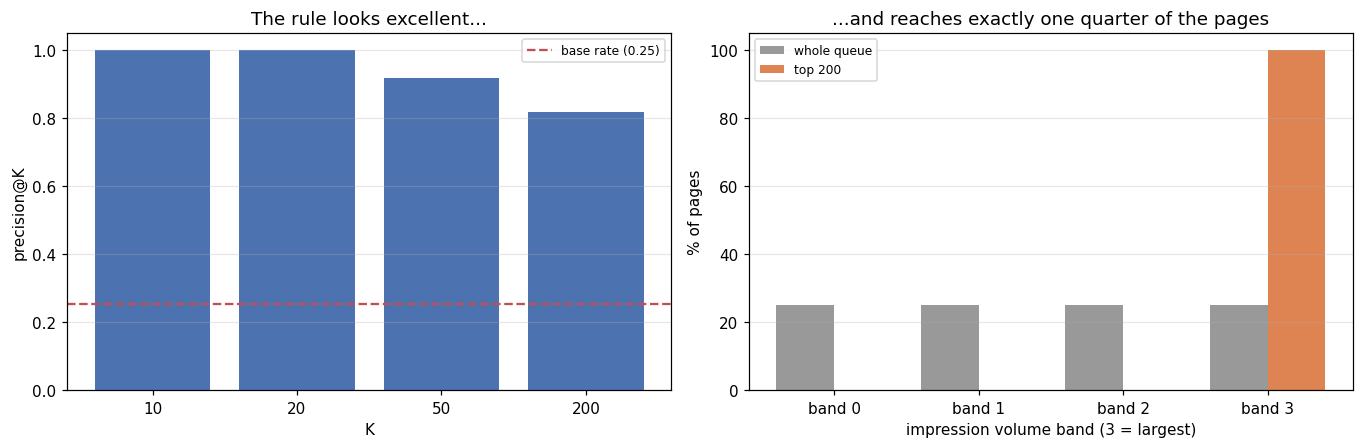

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ks = [10, 20, 50, 200]
sc = ev["shortfall_pp"] * np.log1p(ev["impressions_prev_30d"])
axes[0].bar([str(k) for k in ks], [precision_at_k(ev, sc, k) for k in ks], color="#4C72B0")
axes[0].axhline(BASE_RATE, color="#C44E52", ls="--", lw=1.5,
                label=f"base rate ({BASE_RATE:.2f})")
axes[0].set_xlabel("K"); axes[0].set_ylabel("precision@K"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("The rule looks excellent...")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)

bands = queue["band_prev"].value_counts().sort_index()
t200 = top200["band_prev"].value_counts().reindex(bands.index).fillna(0)
x = np.arange(len(bands))
axes[1].bar(x - 0.2, bands / bands.sum() * 100, width=0.4, label="whole queue", color="#999999")
axes[1].bar(x + 0.2, t200 / 200 * 100, width=0.4, label="top 200", color="#DD8452")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"band {i}" for i in bands.index])
axes[1].set_xlabel("impression volume band (3 = largest)"); axes[1].set_ylabel("% of pages")
axes[1].set_title("...and reaches exactly one quarter of the pages")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("work/outputs/baseline_precision_and_coverage.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/baseline_precision_and_coverage.png  <- committable figure")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only, asserted in section 4
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Two signal verdicts with visible bucket tables and n**, at least one flag-linked — both are:
      CTR-vs-position (**CONFIRMED**, behind the CTR-fix logic) and staleness (**MIXED**, behind the
      refresh flags). The negative verdict removed a term from the rule.
- [x] **One rule with a score, one reason code, an action label** — strict first-match ladder, so every row
      carries exactly one code.
- [x] **A ranked queue written from the notebook** — `work/outputs/baseline_action_score.csv`, 11,119 rows,
      gitignored by design; receipts in `work/outputs/baseline_metrics.json`, which is committable.
- [x] **Ten reviewed rows with "what would make it wrong" for each** — plus risk flags derived in code.
- [x] **No future-window or label-derived inputs** — five asserted guards in section 4.

### Lane decision: CONFIRMED, staying on Lane 4

Lanes lock this week. Three weeks of evidence say stay:

- The population is real — 11,119 scorable pages across 28 clients.
- The signal is real — reason codes separate under-capture from 7.2% to 57.8%, monotonically.
- The baseline is strong but not finished — 0.920 at K=50, and a hand review that found three structural
  faults precision@K could not see. That is the ideal position to be in going into a modelling week: a
  serious opponent with known, nameable weaknesses.

**What would have made me switch:** if Signal 1 had come back MIXED — if CTR had *not* depended on
position — the whole peer-group premise would have collapsed and Lane 1 (signal analysis) would have been
the honest home for the result. It came back CONFIRMED across 5,297 and 2,727 pages, so the premise holds.

### The frozen baseline ML-08 has to beat

| Metric | Value |
|---|---|
| precision@10 | **1.000** |
| precision@20 | **1.000** |
| precision@50 | **0.920** |
| precision@200 | **0.820** |
| base rate | 0.254 |

Frozen as of this run — the skill is right that moving the goalposts mid-game convinces nobody. **Judge the
model at K = 50 and K = 200**, because there is no room to beat 1.000 and pretending otherwise would be a
way of guaranteeing myself a win.

### What ML-08 gets, in priority order
1. **A volume × position peer group** — the fix for weak pick 3, now possible because ML-04 computes
   position inside the feature window only.
2. **Per-client normalisation or a per-client cap** on the queue — the fix for weak pick 2.
3. **Drop or soften the `log1p(impressions)` weight** and measure what coverage costs in precision — the
   fix for weak pick 1.
4. **Split the action ladder**, so `REWRITE_TITLE_META` is not the answer to every question.